<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab2_ipynb_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install fredapi

In [7]:
import pandas as pd
from fredapi import Fred

In [8]:
fred = Fred(api_key='82078b7e0f65bcf75cbf64afe01471d7')

In [9]:
wages = fred.get_series('AHETPI')
cpi = fred.get_series('CPIAUCSL')

df = pd.DataFrame({'Nominal_Wage': wages, 'CPI':cpi})

df = df.dropna()

print(df.head(10))
print(df.tail(10))

            Nominal_Wage    CPI
1964-01-01          2.50  30.94
1964-02-01          2.50  30.91
1964-03-01          2.51  30.94
1964-04-01          2.52  30.95
1964-05-01          2.52  30.98
1964-06-01          2.53  31.01
1964-07-01          2.54  31.02
1964-08-01          2.55  31.05
1964-09-01          2.56  31.08
1964-10-01          2.55  31.12
            Nominal_Wage      CPI
2025-02-01         30.91  319.775
2025-03-01         30.97  319.615
2025-04-01         31.05  320.321
2025-05-01         31.14  320.580
2025-06-01         31.26  321.500
2025-07-01         31.35  322.132
2025-08-01         31.45  323.364
2025-09-01         31.52  324.368
2025-11-01         31.73  325.031
2025-12-01         31.76  326.030


In [16]:
def get_real_wage(nominal_col, cpi_col):

    cpi_today = cpi_col.iloc[-1]

    real_col = (nominal_col / cpi_col) * cpi_today

    return real_col

df['Real_Wage'] = get_real_wage(df['Nominal_Wage'], df['CPI'])

print(df.tail())

            Nominal_Wage      CPI  Real_Wage
2025-07-01         31.35  322.132  31.729355
2025-08-01         31.45  323.364  31.709292
2025-09-01         31.52  324.368  31.681502
2025-11-01         31.73  325.031  31.827524
2025-12-01         31.76  326.030  31.760000


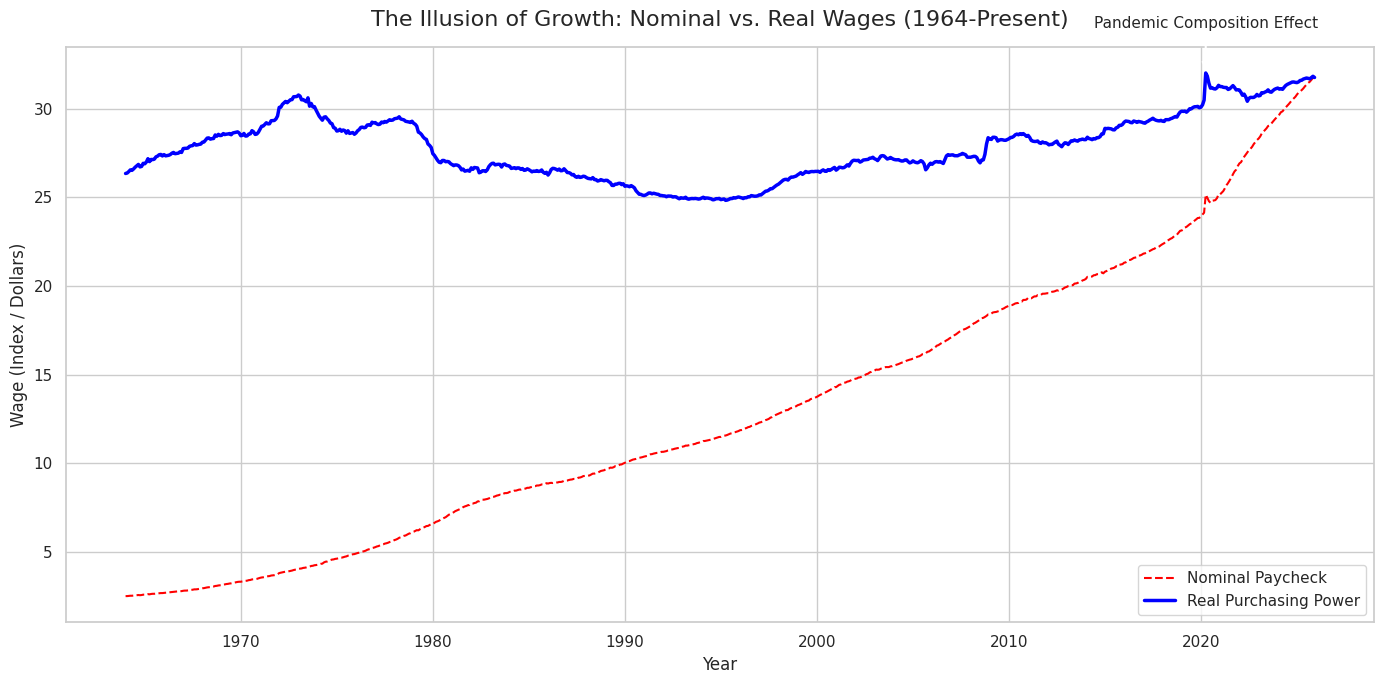

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # only needed for Timestamp / indexing helpers

# Set seaborn style
sns.set_theme(style="whitegrid")

# Make a copy with an explicit date column for seaborn
df_plot = df.copy()
df_plot['Date'] = df_plot.index

# Find the 2020 spike in Real Wages for annotation
df_2020 = df.loc['2020']  # uses DatetimeIndex slicing
spike_date = df_2020['Real_Wage'].idxmax()
spike_value = df_2020['Real_Wage'].max()

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Nominal Wage (dashed red)
sns.lineplot(
    data=df_plot,
    x='Date',
    y='Nominal_Wage',
    ax=ax,
    linestyle='--',
    color='red',
    label='Nominal Paycheck'
)

# Plot Real Wage (thick blue)
sns.lineplot(
    data=df_plot,
    x='Date',
    y='Real_Wage',
    ax=ax,
    linewidth=2.5,
    color='blue',
    label='Real Purchasing Power'
)

# Title and axis labels
ax.set_title('The Illusion of Growth: Nominal vs. Real Wages (1964-Present)', fontsize=16, pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Wage (Index / Dollars)', fontsize=12)

# Annotation for the 2020 spike in Real Wages
ax.annotate(
    'Pandemic Composition Effect',
    xy=(spike_date, spike_value),
    xycoords='data',
    xytext=(spike_date, spike_value * 1.08),  # move text a bit above the spike
    textcoords='data',
    arrowprops=dict(arrowstyle='->', linewidth=1.5),
    fontsize=11,
    ha='center'
)

# Improve layout and legend
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

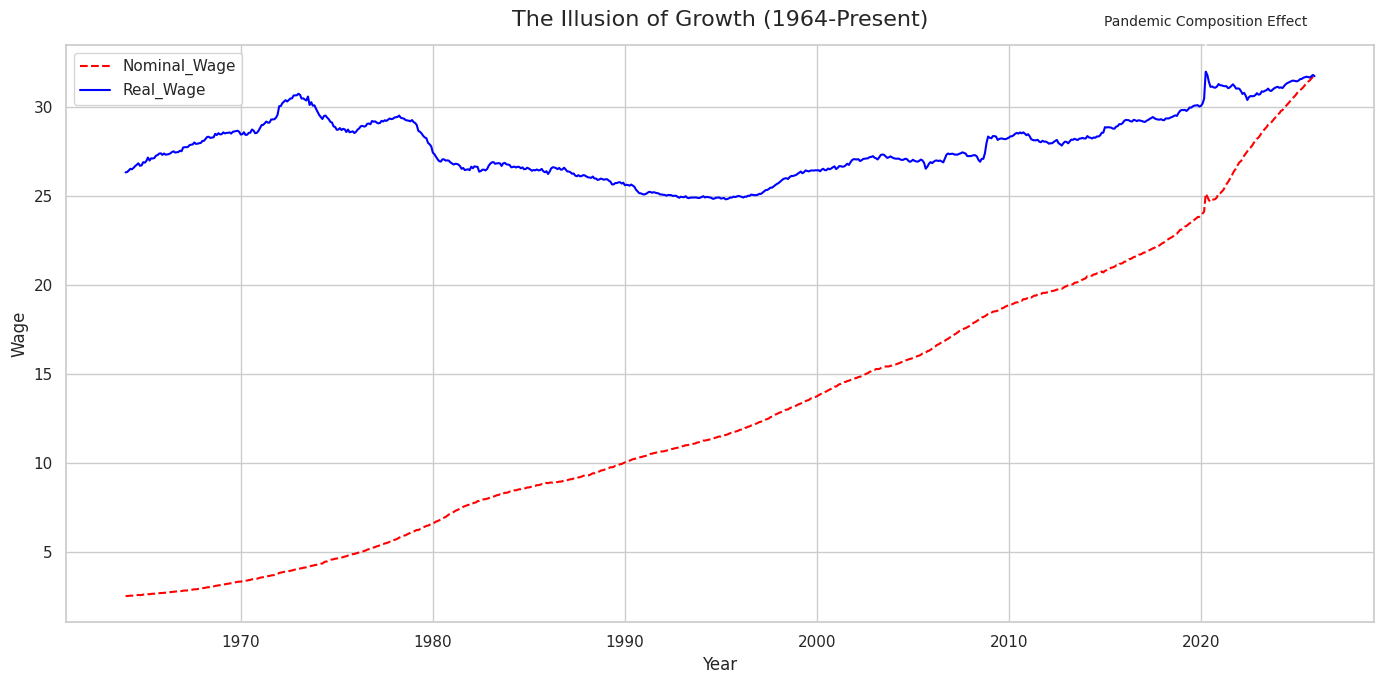

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(14, 7))

# Plot the two series
ax.plot(df.index, df['Nominal_Wage'], linestyle='--', color='red', label='Nominal_Wage')
ax.plot(df.index, df['Real_Wage'], linestyle='-',  color='blue', label='Real_Wage')

# Title + labels
ax.set_title('The Illusion of Growth (1964-Present)', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Wage')

# Find and annotate 2020 spike in Real Wage
df_2020 = df.loc['2020']
spike_date = df_2020['Real_Wage'].idxmax()
spike_value = df_2020['Real_Wage'].max()

ax.annotate(
    'Pandemic Composition Effect',
    xy=(spike_date, spike_value),
    xytext=(spike_date, spike_value * 1.08),
    arrowprops=dict(arrowstyle='->', linewidth=1.3),
    ha='center',
    fontsize=10
)

ax.legend()
plt.tight_layout()
plt.show()

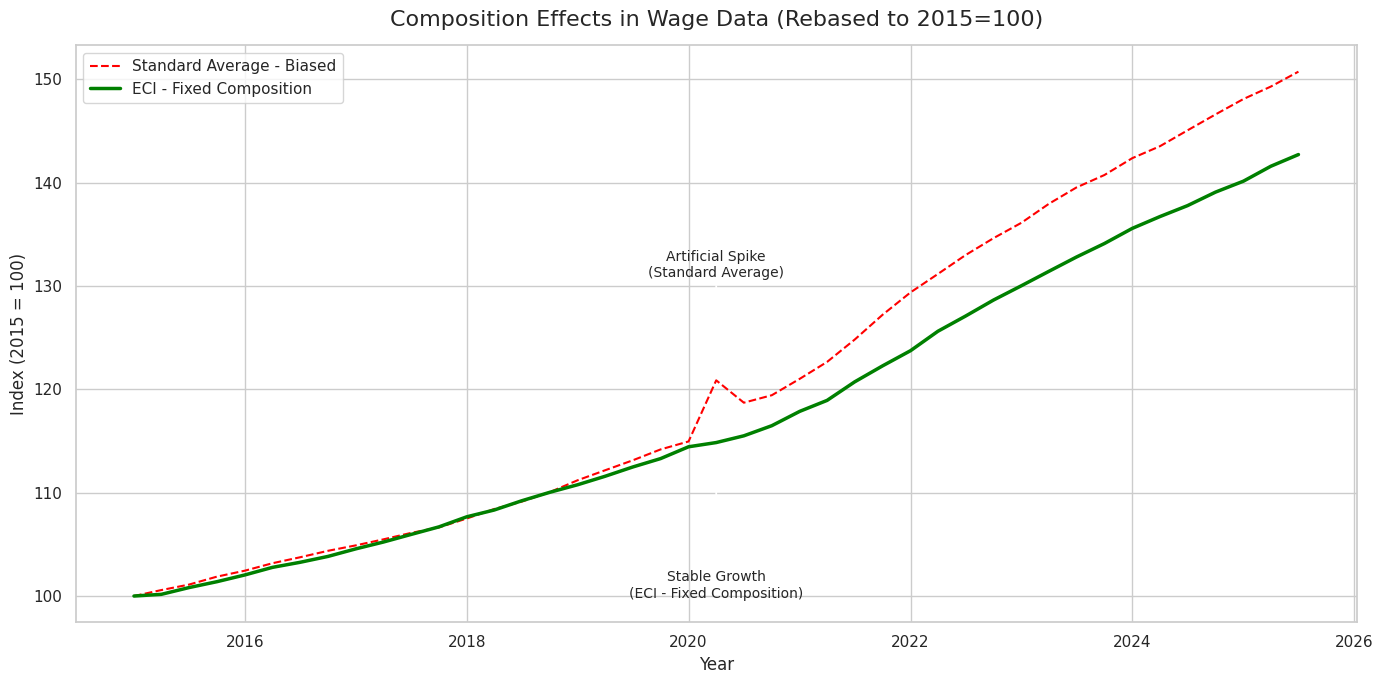

In [20]:
import matplotlib.pyplot as plt

# 1. Fetch ECIWAG from FRED using your existing 'fred' object
# (this assumes fred is e.g. a fredapi.Fred instance)
eci = fred.get_series('ECIWAG')  # returns a pandas Series with a DatetimeIndex

# 2. Filter both series to 2015-01-01 onward
start_date = '2015-01-01'
wages_2015 = wages[wages.index >= start_date]
eci_2015   = eci[eci.index >= start_date]

# Align on common dates (optional but usually a good idea)
common_idx = wages_2015.index.intersection(eci_2015.index)
wages_2015 = wages_2015.loc[common_idx]
eci_2015   = eci_2015.loc[common_idx]

# 3. Rebase both to 100 (divide by first value and multiply by 100)
wages_rebased = wages_2015 / wages_2015.iloc[0] * 100
eci_rebased   = eci_2015   / eci_2015.iloc[0]   * 100

# 4. Plot on same chart
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    wages_rebased.index,
    wages_rebased,
    linestyle='--',
    color='red',
    label='Standard Average - Biased'
)

ax.plot(
    eci_rebased.index,
    eci_rebased,
    linestyle='-',
    linewidth=2.5,
    color='green',
    label='ECI - Fixed Composition'
)

ax.set_title('Composition Effects in Wage Data (Rebased to 2015=100)', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Index (2015 = 100)')

# 5. Annotate divergence in 2020: "Artificial Spike" vs "Stable Growth"
mask_2020 = wages_rebased.index.year == 2020
if mask_2020.any():
    # Find the date in 2020 where the gap between the two is largest
    gap_2020 = (wages_rebased[mask_2020] - eci_rebased[mask_2020]).abs()
    spike_date = gap_2020.idxmax()
    spike_wage = wages_rebased.loc[spike_date]
    spike_eci  = eci_rebased.loc[spike_date]

    # Annotate near the biased series (wages)
    ax.annotate(
        'Artificial Spike\n(Standard Average)',
        xy=(spike_date, spike_wage),
        xytext=(spike_date, spike_wage + 10),
        arrowprops=dict(arrowstyle='->', linewidth=1.3),
        ha='center',
        fontsize=10
    )

    # Optionally annotate the ECI as "Stable Growth"
    ax.annotate(
        'Stable Growth\n(ECI - Fixed Composition)',
        xy=(spike_date, spike_eci),
        xytext=(spike_date, spike_eci - 15),
        arrowprops=dict(arrowstyle='->', linewidth=1.3),
        ha='center',
        fontsize=10
    )

ax.legend()
fig.tight_layout()
plt.show()